# Task 5: Sales Data Analysis
**Dataset:** Superstore Sales Dataset  
**Objective:** Analyze business performance through revenue trends, top products, and profit analysis  
**Name:** Mahek Shaikh

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## Step 1: Load and Inspect the Dataset

In [3]:
df = pd.read_csv('Superstore.csv', encoding='latin-1')
print("Shape:", df.shape)
df.head()

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


## Step 2: Data Preprocessing

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%b')
print("Date columns converted successfully.")
df.head(3)

Date columns converted successfully.


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,2016,11,Nov
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,2016,11,Nov
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,2016,6,Jun


## Step 3: Monthly Revenue Trends

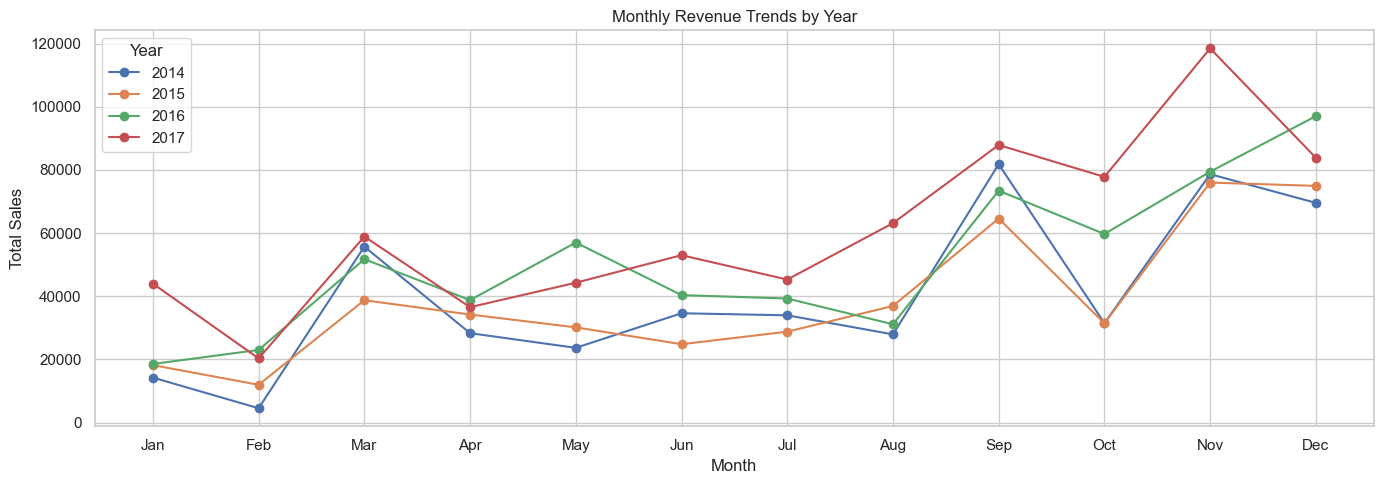

Observation: Sales consistently spike towards the end of the year (Nov-Dec), likely due to holiday season demand.


In [7]:
monthly = df.groupby(['Year', 'Month', 'Month Name'])['Sales'].sum().reset_index()
monthly = monthly.sort_values(['Year', 'Month'])

plt.figure(figsize=(14,5))
for year in monthly['Year'].unique():
    data = monthly[monthly['Year'] == year]
    plt.plot(data['Month Name'], data['Sales'], marker='o', label=str(year))

plt.title('Monthly Revenue Trends by Year')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

print("Observation: Sales consistently spike towards the end of the year (Nov-Dec), likely due to holiday season demand.")

## Step 4: Top 10 Best-Selling Products

C:\Users\MAHEK\AppData\Local\Temp\ipykernel_27640\840754578.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='Blues_r')


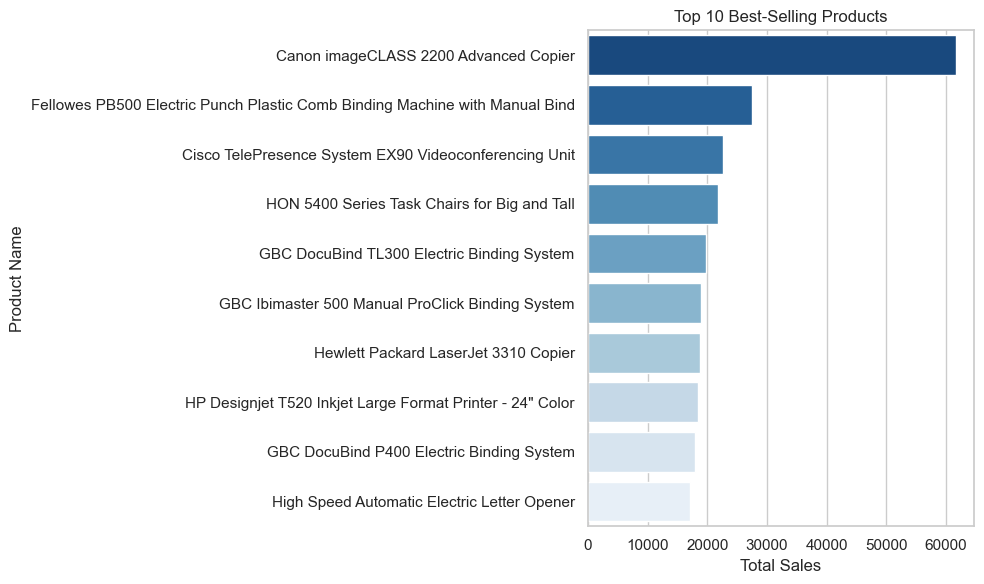

Observation: Phones and Chairs are among the highest revenue-generating products.


In [8]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index, palette='Blues_r')
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Total Sales')
plt.tight_layout()
plt.show()

print("Observation: Phones and Chairs are among the highest revenue-generating products.")

## Step 5: Profit Analysis by Category

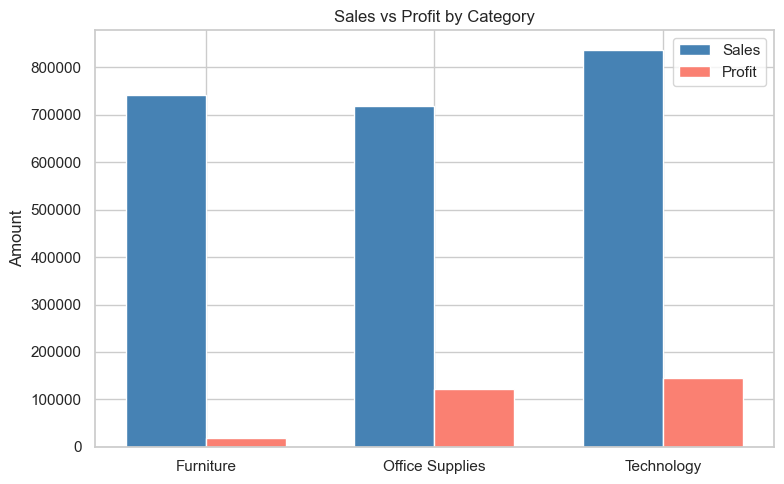

Observation: Technology has the highest profit margin. Furniture has high sales but low profit.


In [9]:
category_profit = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()

x = np.arange(len(category_profit['Category']))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width/2, category_profit['Sales'], width, label='Sales', color='steelblue')
ax.bar(x + width/2, category_profit['Profit'], width, label='Profit', color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(category_profit['Category'])
ax.set_title('Sales vs Profit by Category')
ax.set_ylabel('Amount')
ax.legend()
plt.tight_layout()
plt.show()

print("Observation: Technology has the highest profit margin. Furniture has high sales but low profit.")

## Step 6: Sales by Region

C:\Users\MAHEK\AppData\Local\Temp\ipykernel_27640\1956460649.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.index, y=region_sales.values, palette='Greens_r')


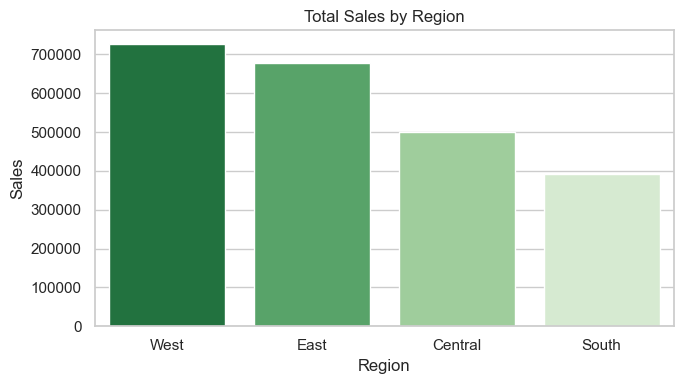

Observation: West region generates the highest sales, followed by East.


In [10]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(x=region_sales.index, y=region_sales.values, palette='Greens_r')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

print("Observation: West region generates the highest sales, followed by East.")

## Step 7: Profit by sub-category

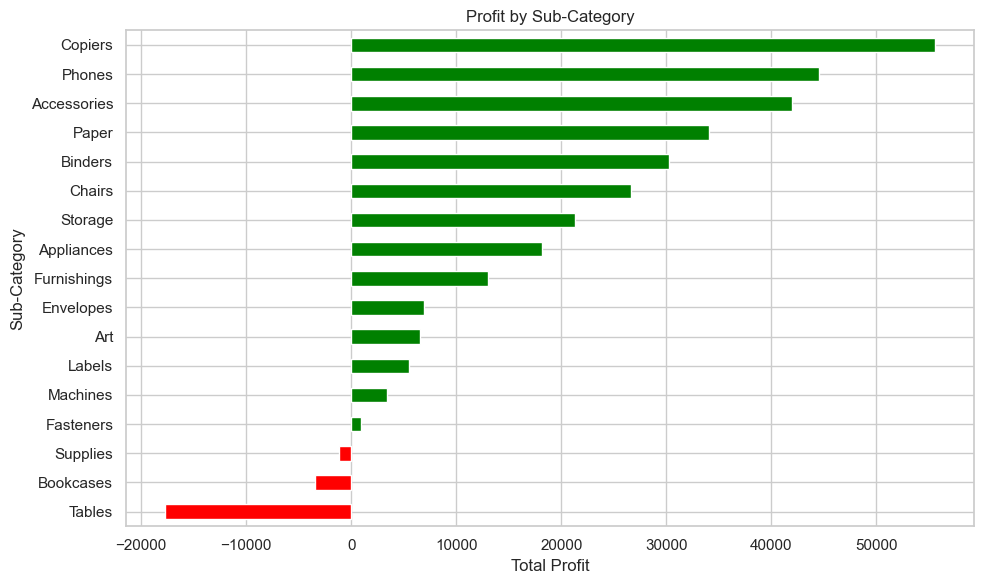

Observation: Tables and Bookcases are running at a loss. Copiers and Phones are most profitable.


In [11]:
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

plt.figure(figsize=(10,6))
sub_profit.plot(kind='barh', color=['red' if x < 0 else 'green' for x in sub_profit])
plt.title('Profit by Sub-Category')
plt.xlabel('Total Profit')
plt.tight_layout()
plt.show()

print("Observation: Tables and Bookcases are running at a loss. Copiers and Phones are most profitable.")